# Test 6
## APCEMM PCE Creation
Aircraft Type: B737-800

Engine Type: CFM56

### Initial Conditions
RHi Mean: 117

RHi Normalized Variance: 100

### Temporal Conditions
RHi Normalized Variance: 100


In [1]:
# APCEMM Application of PCE
import numpy as np
import scipy as sc
import totalOrderMultiIndexSet
from numpy.polynomial.hermite_e import HermiteE
from matplotlib.lines import Line2D
from matplotlib import pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)
import tqdm
import time

In [2]:
### PCE CREATION FUNCTION LIBRARY ###

### Create and Validate PCE ###
def create_PCE(sample_type:str, training_runs:int):
    print(f"Creating PCE for {sample_type} samples with {training_runs} training runs.")
    c, alpha_set = compute_c(sample_type, training_runs)
    return c, alpha_set

def predicted_novel_solutions(c, alpha_set, novel_runs): # Novel inputs to PCE from online samples
    sample_type = "novel"
    multiindices = alpha_set.shape[0]
    He_array = np.zeros((multiindices, novel_runs))
    samples_matrix = get_samples_matrix_online(novel_runs, sample_type)

    for i in tqdm.tqdm(range(novel_runs)): # for each MC run
        for j in range(multiindices): # for each coefficient
            current_alpha = alpha_set[j, :] # look at one row at a time for all alpha describing a single coefficient
            samples_matrix_He = samples_matrix[i, :]
            He_array[j, i] = compute_He(samples_matrix_He, current_alpha)

    # Solve for the Least Squares solution
    predicted_output = c.T @ He_array
    return predicted_output.T

def true_training_solutions(sample_type:str):
    true_output = func_eval_offline(sample_type).T # TRUE APCEMM SOLUTIONS [Integrated VOD] with shape: (number of datasets to train PCE, timesteps)
    return true_output

### NEED TO UPDATE OFFLINE FUNCTIONS TO DISTINGUISH VALIDATION AND TRAINING PATHS
def predicted_validation_solutions(c, alpha_set, validation_runs): # Validation inputs to PCE from offline pre-computed validation set
    sample_type = "validation"
    multiindices = alpha_set.shape[0]
    He_array = np.zeros((multiindices, validation_runs))
    samples_matrix = get_samples_matrix_offline(sample_type)

    for i in tqdm.tqdm(range(validation_runs)): # for each MC run
        
        for j in range(multiindices): # for each coefficient
            current_alpha = alpha_set[j, :] # look at one row at a time for all alpha describing a single coefficient
            samples_matrix_He = samples_matrix[i, :]
            He_array[j, i] = compute_He(samples_matrix_He, current_alpha)

    # Solve for the Least Squares solution
    predicted_output = (c.T @ He_array).T

    return predicted_output

def true_validation_solutions(sample_type:str):
    true_output = func_eval_offline(sample_type).T # TRUE APCEMM SOLUTIONS [Integrated VOD] with shape: (number of datasets to train PCE, timesteps)
    return true_output

### Internal Functions ###
def compute_c(sample_type:str, training_runs):

    c_samples_matrix = get_samples_matrix_offline(sample_type) # (timesteps, number of datasets to train PCE)
    alpha_set = get_alpha_set()
    c_multiindices = alpha_set.shape[0]

    V = np.zeros((training_runs, c_multiindices)) # Vandermonde Matrix: Training Runs x Degree of Polynomial

    for i in tqdm.tqdm(range(training_runs)):
        for j in range(c_multiindices):
            current_alpha = alpha_set[j, :]
            c_samples_matrix_He = c_samples_matrix[:, i]
            V[i, j] = compute_He(c_samples_matrix_He, current_alpha) / np.sqrt(np.product(sc.special.factorial(current_alpha)))

    f = solve_u(sample_type).T # (number of datasets to train PCE, timesteps)
    
    c, residuals, rank, singular_values = np.linalg.lstsq(V.T @ V, V.T @ f)
    
    return c, alpha_set

def func_eval_offline(sample_type:str):
    if sample_type == "training":
        training_samples_matrix_offline_OUTPUTS = training_samples_matrix_offline[1,:,:] # (depth, row, column) --> (0=input 1=output, number of datasets to train PCE, timesteps)
        # Transpose the rows and columns to accomodate later calculations
        training_samples_matrix_offline_OUTPUTS = training_samples_matrix_offline_OUTPUTS.T # (timesteps, number of datasets to train PCE)
        return training_samples_matrix_offline_OUTPUTS
    
    elif sample_type == "validation":
        validation_samples_matrix_offline_OUTPUTS = validation_samples_matrix_offline[1,:,:]
        validation_samples_matrix_offline_OUTPUTS = validation_samples_matrix_offline_OUTPUTS.T
        return validation_samples_matrix_offline_OUTPUTS
    
    else: 
        print("Invalid sample type. Please enter 'training' or 'validation'.")
        return None


def get_samples_matrix_offline(sample_type:str):

    if sample_type == "training":
        training_samples_matrix_offline_INPUTS = training_samples_matrix_offline[0,:,:] # (depth, row, column) --> (0=input 1=output, number of datasets to train PCE, timesteps)
        training_samples_matrix_offline_INPUTS = training_samples_matrix_offline_INPUTS.T # (timesteps, number of datasets to train PCE)
        print(training_samples_matrix_offline_INPUTS.shape)
        return training_samples_matrix_offline_INPUTS
    
    elif sample_type == "validation":
        validation_samples_matrix_offline_INPUTS = validation_samples_matrix_offline[0,:,:] # (depth, row, column) --> (0=input 1=output, number of datasets, timesteps)
        validation_samples_matrix_offline_INPUTS = validation_samples_matrix_offline_INPUTS.T # (timesteps, number of datasets)
        return validation_samples_matrix_offline_INPUTS

    else: 
        print("Invalid sample type. Please enter 'training' or 'validation'.")
        return None
    
def get_samples_matrix_online(runs):
    return np.hstack((np.random.normal(mean_IC_norm, std_IC, size=(runs, 1)), np.random.normal(mean_norm, std_norm, size=(runs, timesteps - 1))))

def get_alpha_set():
    return totalOrderMultiIndexSet.totalOrderMultiIndices(poly_dim, max_deg)

def compute_He(Z, alpha):
    res = 1
    for alpha_i, z_i in zip(alpha, Z):
        res = res * HermiteE.basis(deg = alpha_i)(z_i)
    return res

def solve_u(sample_type:str):
    u_sol = func_eval_offline(sample_type) # (timesteps, number of datasets to train PCE)
    return u_sol

#-----------------------------------------------------------------------------------
### SENSITIVITY ANALYSIS ###
def compute_total_effect_sensitivity_indices(coefficients, num_variables):
    """
    Compute total effect sensitivity indices for each uncertain variable.

    Parameters:
    coefficients (numpy.ndarray): Simulated coefficients, rows represent different basis terms, columns represent timesteps.
    num_variables (int): Number of uncertain variables.

    Returns:
    dict: Dictionary containing total effect sensitivity indices for each variable.
    """
    # Number of basis terms
    num_basis = coefficients.shape[0]

    # Compute total variance for each timestep (sum of squared coefficients excluding the constant term)
    total_variance = np.sum(coefficients[1:, :] ** 2, axis=0)  # Sum across basis terms, excluding the first row

    # Dictionary to store total effect sensitivity indices
    S_T = {}

    # Assuming that each variable's basis functions are in consecutive blocks, 
    # we will group basis terms by the uncertain variables they correspond to.
    for var_idx in range(num_variables):
        # For each uncertain variable, sum over the basis terms that correspond to that variable.
        # Assuming here that each variable's terms are grouped consecutively in the matrix:
        start_idx = var_idx * (num_basis // num_variables)  # Starting index for this variable's terms
        end_idx = start_idx + (num_basis // num_variables)  # Ending index for this variable's terms

        # Sum over all terms that involve this variable (main effect + interactions)
        variance_contribution = np.sum(coefficients[start_idx:end_idx, :] ** 2, axis=0)  # Sum over terms for this variable
        S_T[f"S_T_{var_idx}"] = variance_contribution / total_variance

    return S_T

### Define Constants and PCE Parameters

In [3]:
# Define test identifiers
test_id = 'test_6'

# Define constants
training_runs = 20 # Number of APCEMM runs for training
timesteps = 73 # Number of samples per APCEMM run (this is the number of timesteps per run) # 20 hours
max_deg = 2 # Maximum value of sum of degrees across the number of uncertain variables (AKA sum of each row of alpha_set must be less than or equal to the max_deg)
poly_dim = 1 # Number of random variables
validation_runs = 20 # Number of APCEMM runs for validation

# APCEMM inputs and outputs that were trained on
training_samples_matrix_offline = np.load('/home/chinahg/GCresearch/contrailuncertainty/PCE/APCEMM_training_sets/{}/outputs/training/training_sample_matrix.npy'.format(test_id)) # Import APCEMM training data
# APCEMM inputs that were not trained on, and we also have the True solution for
validation_samples_matrix_offline = np.load('/home/chinahg/GCresearch/contrailuncertainty/PCE/APCEMM_training_sets/{}/outputs/validation/validation_sample_matrix.npy'.format(test_id)) # Import APCEMM validation data

### Smooth any APCEMM artifacts before training and validation

In [4]:
def smooth_artifacts(offline_samples_matrix):

    y = offline_samples_matrix # Extract the output for the i-th training run
    # Step 1: Find large jumps (spikes)
    diff_y = np.abs(np.diff(y))
    threshold = 500  # You can adjust this
    spike_indices = np.where(diff_y > threshold)[0]
    # Step 2: Mask the spike region
    mask = np.ones_like(y, dtype=bool)
    for idx in spike_indices:
        mask[max(0, idx-1):min(len(y), idx+5)] = False  # mask +- some points
    # Step 3: Interpolate to fill spike
    x = np.arange(len(y))
    y_cleaned = np.copy(y)
    y_cleaned[~mask] = np.interp(x[~mask], x[mask], y[mask])
    
    return y_cleaned

for i in range(training_runs):
    training_samples_matrix_offline[1, i, :] = smooth_artifacts(training_samples_matrix_offline[1,i,:])
for i in range(validation_runs):
    validation_samples_matrix_offline[1, i, :] = smooth_artifacts(validation_samples_matrix_offline[1,i,:])


### Create PCE and Record Predicted Outputs and Coefficients

In [5]:
# Create the PCE
sample_type = "training"
coefficients, alpha = create_PCE(sample_type, training_runs)

Creating PCE for training samples with 20 training runs.
(73, 20)


100%|██████████| 20/20 [00:00<00:00, 57.54it/s]
/tmp/ipykernel_3381412/688575904.py:69: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  c, residuals, rank, singular_values = np.linalg.lstsq(V.T @ V, V.T @ f)


In [6]:
sample_type = "training"
true_training_solutions = true_training_solutions(sample_type)

In [7]:
sample_type = "validation"
validation_runs = 20
predicted_validation_solutions = predicted_validation_solutions(coefficients, alpha, validation_runs)
true_validation_solutions = true_validation_solutions(sample_type)

100%|██████████| 20/20 [00:00<00:00, 4409.95it/s]


### Plot PCE Solution vs Training Data

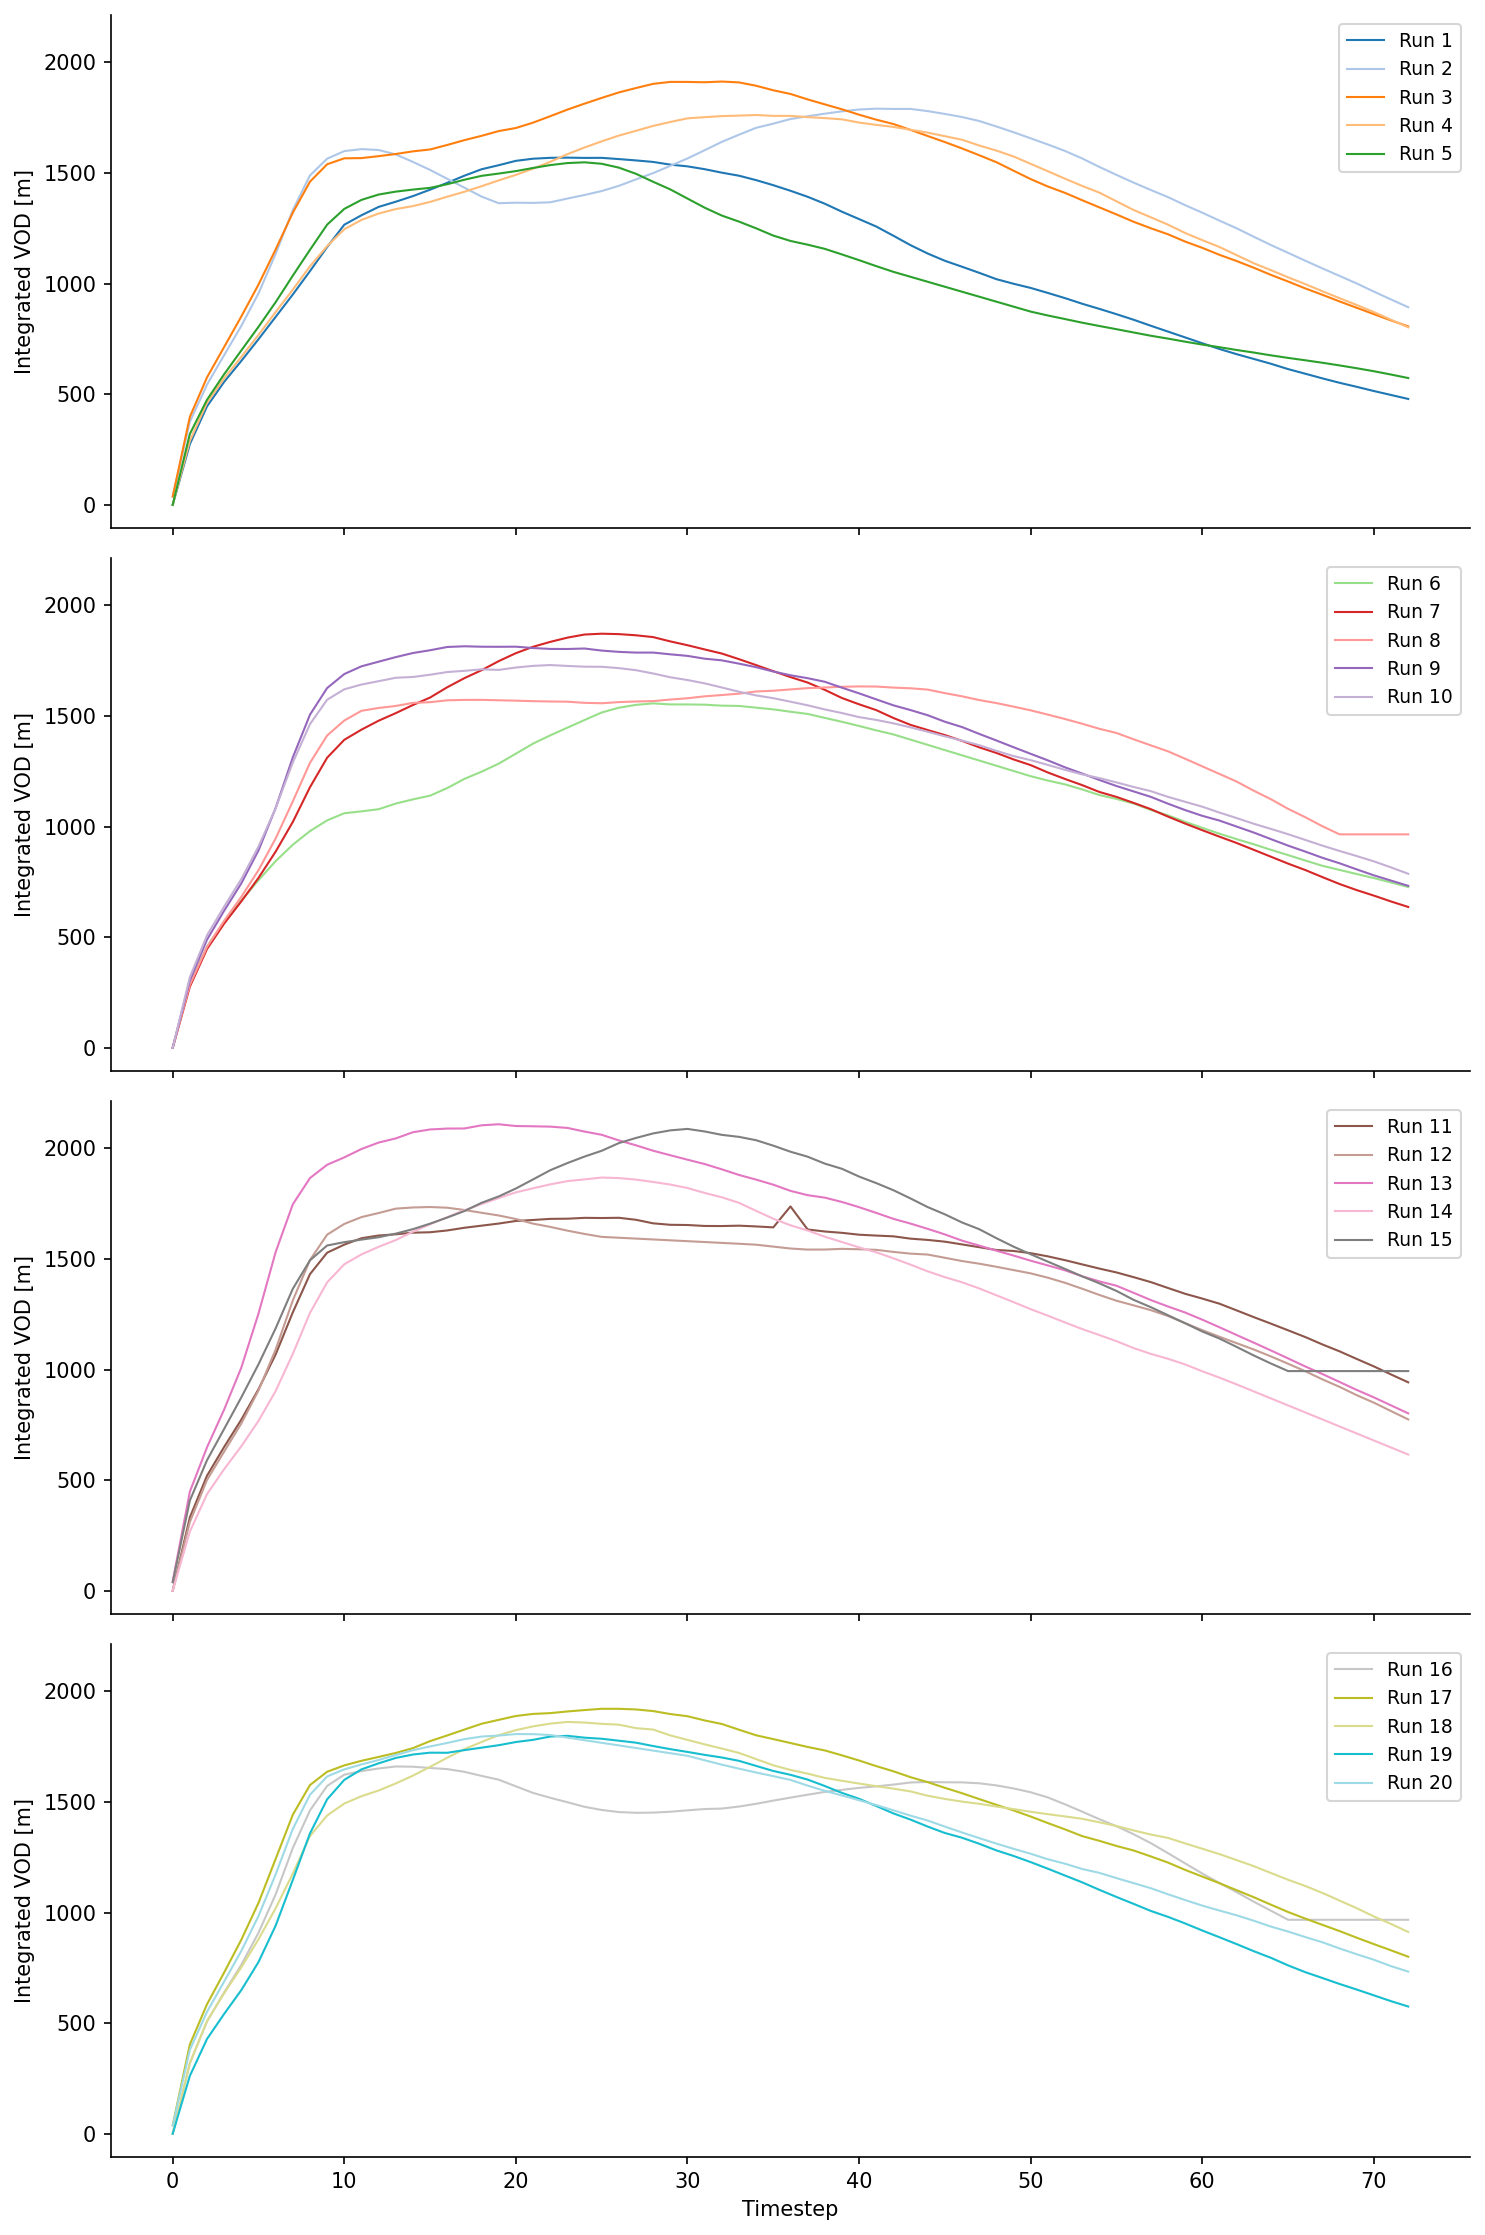

In [9]:
from matplotlib import cm

# Define a colormap and generate unique colors
num_colors = training_runs  # Number of unique colors needed
colors = cm.get_cmap('tab20', num_colors).colors  # Use 'tab20' colormap with `num_colors` unique colors

lw = 1
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(10, 15), dpi=150, sharex=True, sharey=True)

for subplot_idx, ax in enumerate(axes):
    for idx in range(subplot_idx * 5, (subplot_idx + 1) * 5):
        ax.plot(list(range(0, timesteps)), true_training_solutions[idx, :], label=f"Run {idx+1}", lw=lw, color=colors[idx % num_colors])
    ax.set_ylabel("Integrated VOD [m]")
    ax.legend(fontsize=9)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

axes[-1].set_xlabel("Timestep")
plt.tight_layout()
plt.show()


### Validation of PCE created surrogate

In [ ]:
selected_runs = [2, 3, 5, 13, 15, 16]
fig, axes = plt.subplots(nrows=len(selected_runs), ncols=1, figsize=(10, 15), dpi=150, sharex=True)

time_min = timesteps * 10
time_points = np.linspace(0, time_min, timesteps)
line_styles = ["-", "--"]  # Solid, dashed
colors = plt.cm.tab10.colors[:len(selected_runs)]

for idx, run in enumerate(selected_runs):
    ax = axes[idx]
    ax.plot(time_points, true_validation_solutions[run, :], label=f"Run {run+1} - True", color=colors[idx % len(colors)], lw=lw, ls=line_styles[0])
    ax.plot(time_points, predicted_validation_solutions[run, :], label=f"Run {run+1} - PCE", color=colors[idx % len(colors)], lw=lw, ls=line_styles[1])
    ax.set_ylabel("Integrated VOD [m]")
    ax.legend(fontsize=9)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

axes[-1].set_xlabel("Timestep [min]")
plt.tight_layout()
plt.show()


In [ ]:
fig, axes = plt.subplots(nrows=len(selected_runs), ncols=1, figsize=(10, 15), dpi=150, sharex=True)

time_min = timesteps * 10
time_points = np.linspace(0, time_min, timesteps)
line_styles = ["-", "--"]  # Solid, dashed
colors = plt.cm.tab10.colors[:len(selected_runs)]
validation_variance = np.zeros(timesteps)

# Calculate variance for the true validation solutions
for i in range(timesteps):
    validation_variance[i] = np.std(true_validation_solutions[:, i], axis=0)

# Determine global y-axis limits
y_min = min((true_validation_solutions - validation_variance).min(), predicted_validation_solutions.min())
y_max = max((true_validation_solutions + validation_variance).max(), predicted_validation_solutions.max())

# Plot each selected validation run
for idx, run in enumerate(selected_runs):
    ax = axes[idx]
    initial_condition = validation_samples_matrix_offline[0, run, 0] + 117  # Extract the initial condition for the run
    ax.plot(time_points, true_validation_solutions[run, :], label=f"Run {run+1} - True (IC: {initial_condition:.2f})", color=colors[idx % len(colors)], lw=lw, ls=line_styles[0])
    ax.plot(time_points, predicted_validation_solutions[run, :], label=f"Run {run+1} - PCE", color=colors[idx % len(colors)], lw=lw, ls=line_styles[1])
    ax.fill_between(time_points, 
                    true_validation_solutions[run, :] - validation_variance, 
                    true_validation_solutions[run, :] + validation_variance, 
                    color=colors[idx % len(colors)], 
                    alpha=0.2, 
                    label=f"Run {run+1} - Standard Deviation")
    ax.set_ylabel("Integrated VOD [m]")
    ax.legend(fontsize=9)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.set_ylim(y_min, y_max)  # Set the same y-axis limits for all subplots

# Set the x-axis label for the last subplot
axes[-1].set_xlabel("Timestep [min]")

# Adjust layout
plt.tight_layout()
plt.show()


In [ ]:
# Flatten the validation samples to create a 1D array for the histogram
data = validation_samples_matrix_offline[0, :, 0] + 117

# Create the histogram
plt.figure(figsize=(10, 6))
plt.hist(data, bins=50, alpha=0.7, color='blue', edgecolor='black')

# Add integer ticks for the x-axis
x_ticks = range(int(data.min()), int(data.max()) + 1)  # Generate integer ticks
plt.xticks(x_ticks)

plt.xlabel("Validation Sample Values")
plt.ylabel("Frequency")
plt.title("Histogram of Validation Sample Values")
plt.tight_layout()
plt.show()


# Sensitivity Analysis of Novel-Sampled PCE Solutions

In [ ]:
from IPython.display import Image

# Display the image
image_path = '/home/chinahg/GCresearch/contrailuncertainty/PCE/PCE_processing/multi_indices_expl.png'
Image(filename=image_path)

In [ ]:
# Example usage
num_variables = 3
S_T = compute_total_effect_sensitivity_indices(coefficients, num_variables)

# Print the total effect sensitivity indices for the first few timesteps
print("Total Effect Sensitivity Indices (S_T) for first few timesteps:")
for key, values in S_T.items():
    print(f"{key}: {values[:5]}")  # Print first 5 timesteps for brevity

In [ ]:
"training" == sample_type